In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mirichoi0218/insurance")

print("Path to dataset files:", path)

100%|██████████| 16.0k/16.0k [00:00<00:00, 10.1MB/s]

Extracting files...
Path to dataset files: C:\Users\manas\.cache\kagglehub\datasets\mirichoi0218\insurance\versions\1


In [21]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings 

warnings.filterwarnings("ignore")


In [22]:
df = pd.read_csv("insurance.csv")
df.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [24]:
newList = ["sex" , "smoker" , "region"]
for i in newList:
    print(f"Unique values in {i} column: {df[i].unique()}" , end="\n\n")
    print(f"Unique values in {i} column: {df[i].nunique()}" , end = "\n\n")
    print("-" * 50)



Unique values in sex column: ['female' 'male']

Unique values in sex column: 2

--------------------------------------------------
Unique values in smoker column: ['yes' 'no']

Unique values in smoker column: 2

--------------------------------------------------
Unique values in region column: ['southwest' 'southeast' 'northwest' 'northeast']

Unique values in region column: 4

--------------------------------------------------


In [25]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(exclude=np.number).columns.tolist()


numerical_cols , categorical_cols

(['age', 'bmi', 'children', 'charges'], ['sex', 'smoker', 'region'])

In [26]:
df["sex"] = np.where(df["sex"] == "female" , 0 , 1)

df["smoker"] = np.where(df["smoker"] == "no" , 0 , 1)

df["region"] = df["region"].map({"southwest" : 0 , "southeast" : 1 , "northwest" : 2 , "northeast" : 3})




In [27]:
df.head()


,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,0,16884.92400
1,18,1,33.770,1,0,1,1725.55230
2,28,1,33.000,3,0,1,4449.46200
3,33,1,22.705,0,0,2,21984.47061
4,32,1,28.880,0,0,2,3866.85520


In [28]:
# we now have to perform the action of the data scaling as the charges are not in range of the scale of other numerical features 
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = df.drop("charges" , axis=1)
y = df["charges"]


from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(X ,y , test_size=0.2 , random_state=42)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



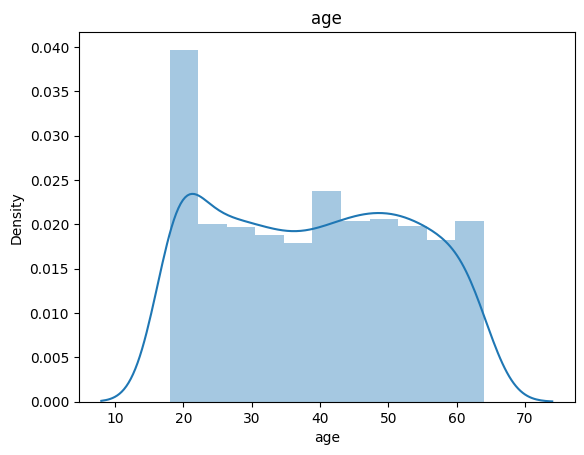

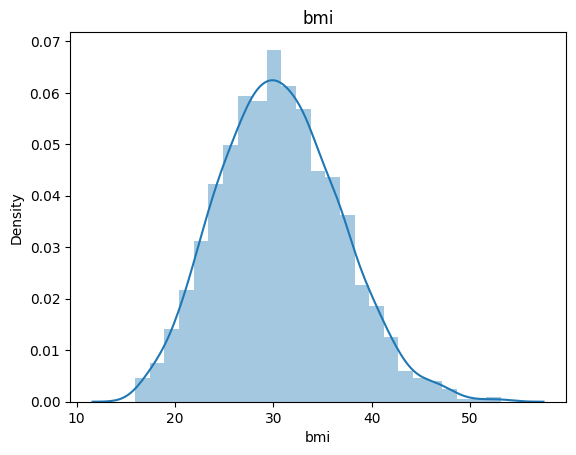

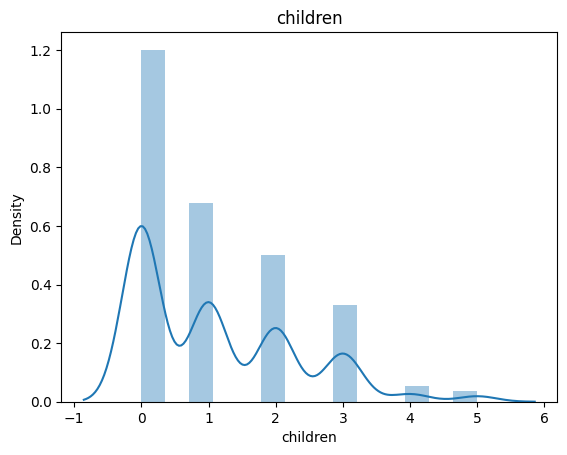

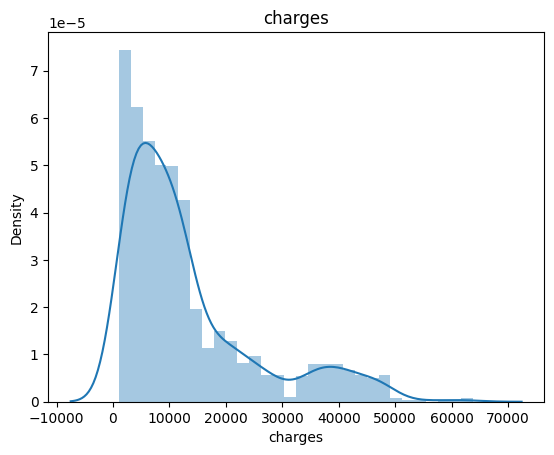

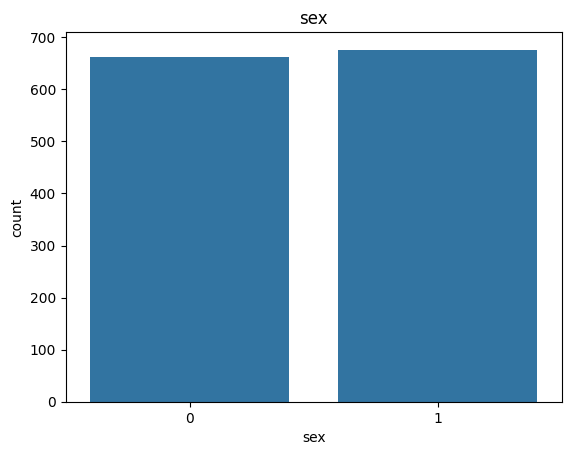

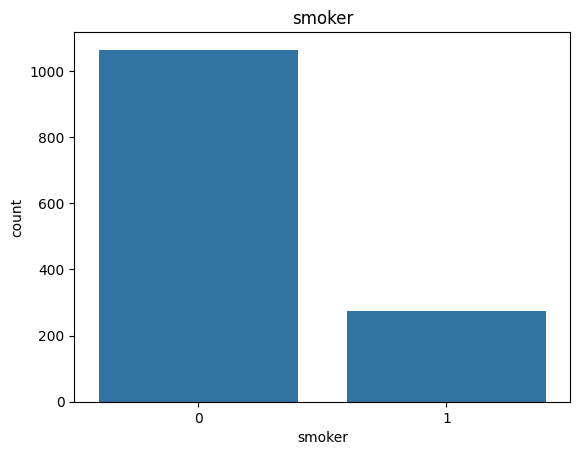

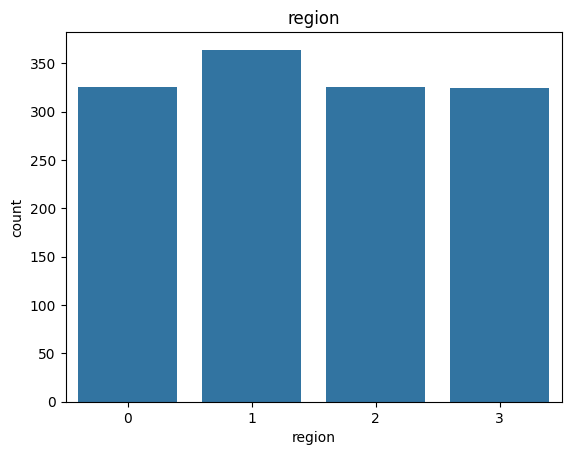

In [31]:
# for the numerical data let's visualise the data 

for i in range(len(numerical_cols)):
    sns.distplot(df[numerical_cols[i]], label=numerical_cols[i])
    plt.title(numerical_cols[i])
    plt.show()


for i in range(len(categorical_cols)):
    sns.countplot(x=categorical_cols[i] , data=df)
    plt.title(categorical_cols[i])
    plt.show()

In [32]:
# the inference that we can make is that the cost of the medical insurance is directly proportional to the number of doctors that are required to treat the patient.
# And also that the data is skewed as the dsitribution of the cost is skewed towards the high end of the 
# 
# cost of the medical insurance is directly proportional to the age of the patient and also to the bmi of the patient as well as to the number of children that the patient has.
# And also that the cost of the medical insurance is directly proportional to the fact that whether the patient is a smoker or not as the cost of the medical insurance is higher for the smokers as compared to the non smokers.



Shape: (1338, 7)

Missing values:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Duplicate rows: 1


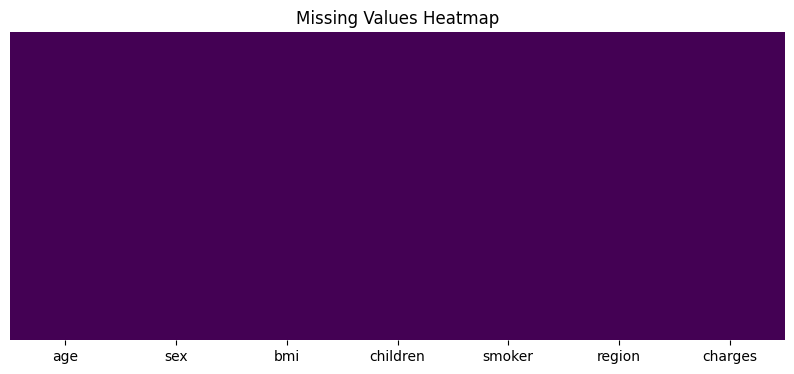

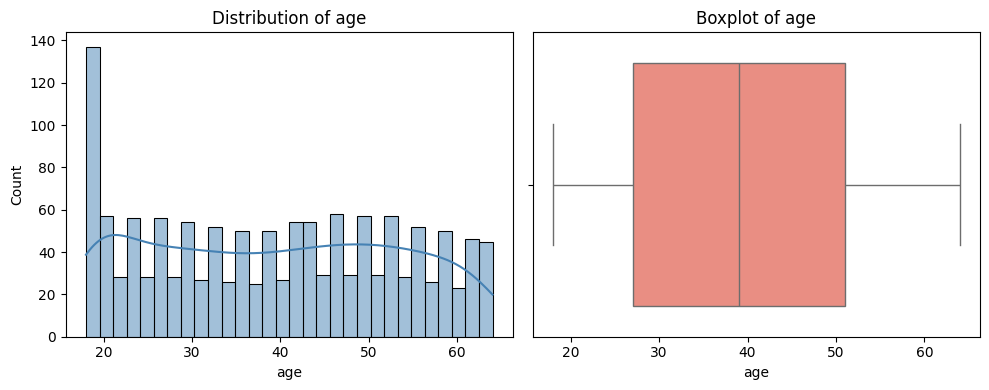

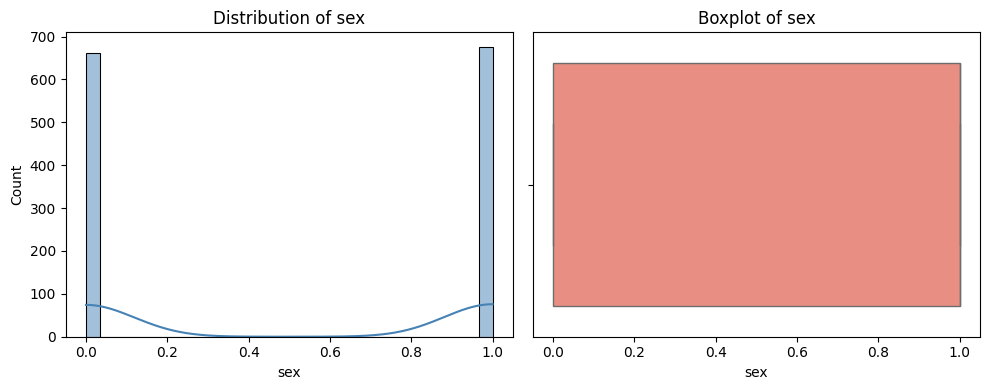

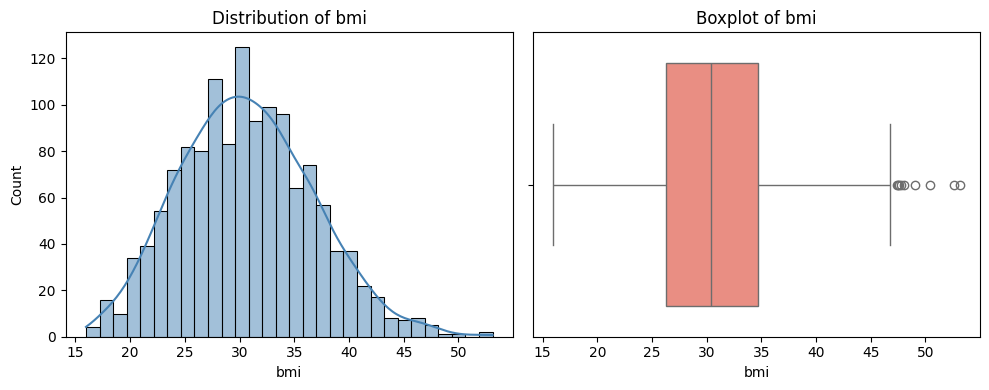

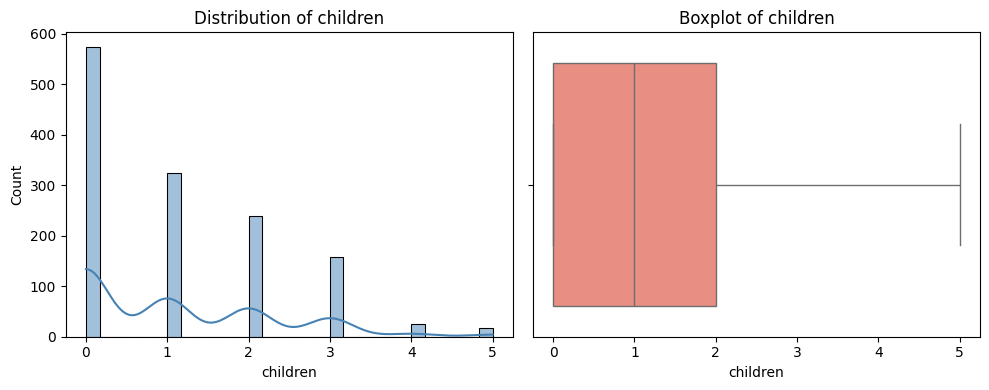

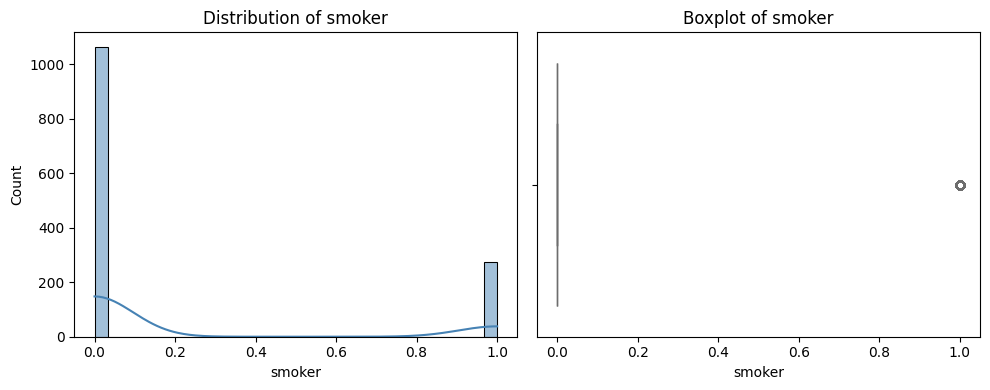

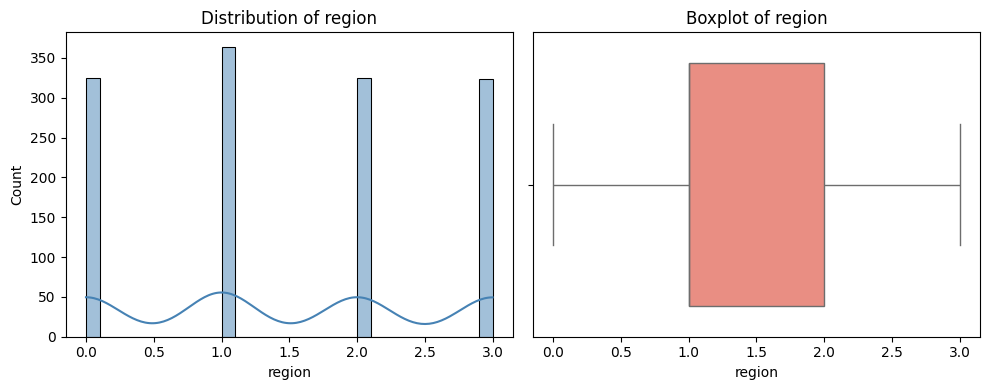

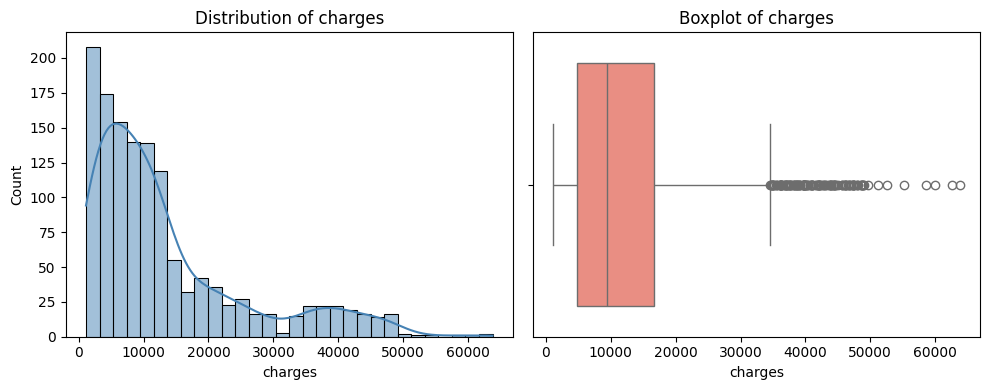

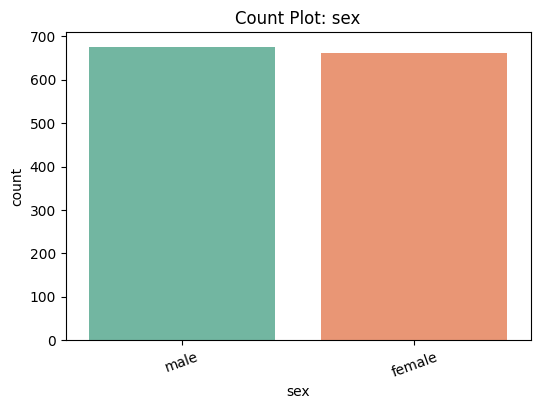

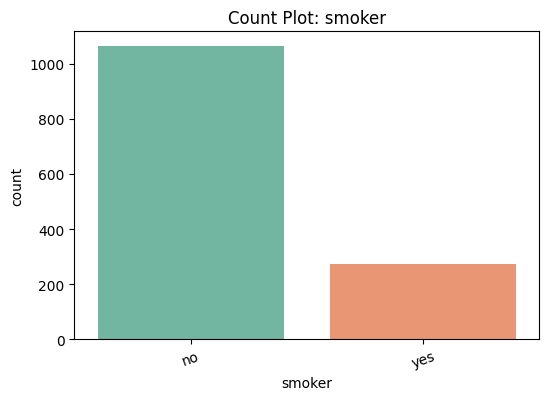

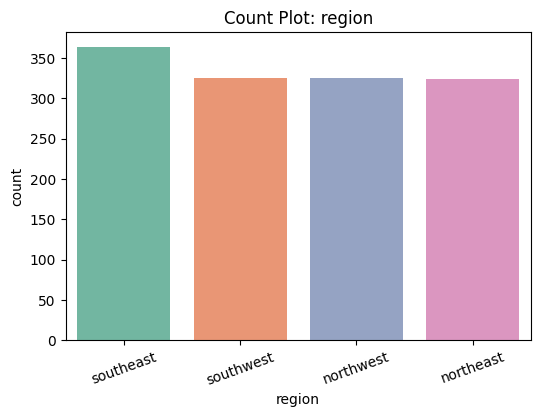

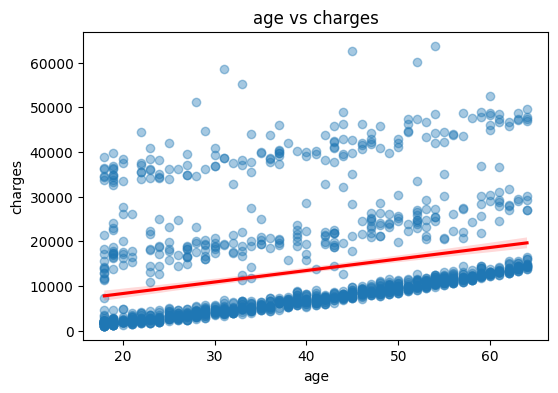

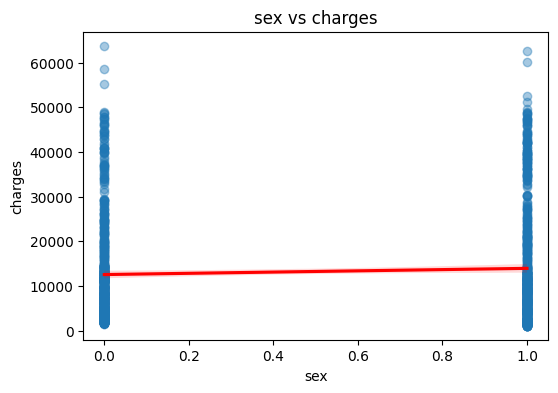

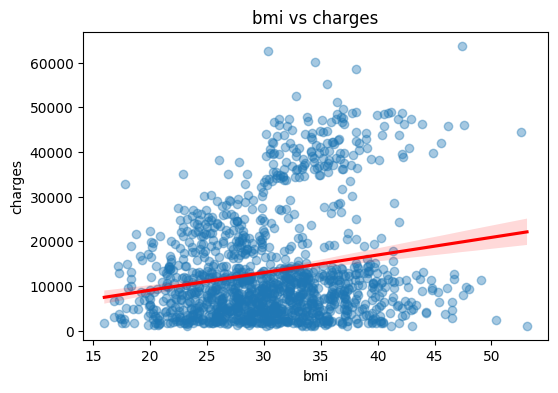

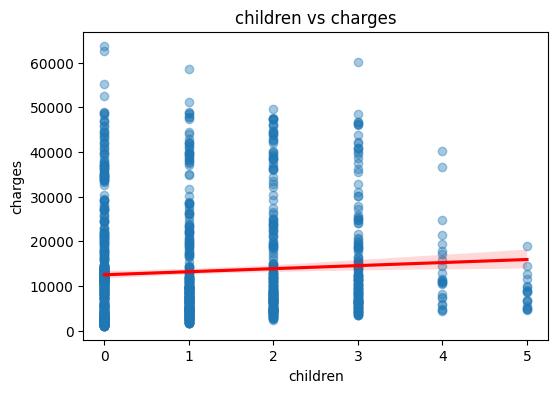

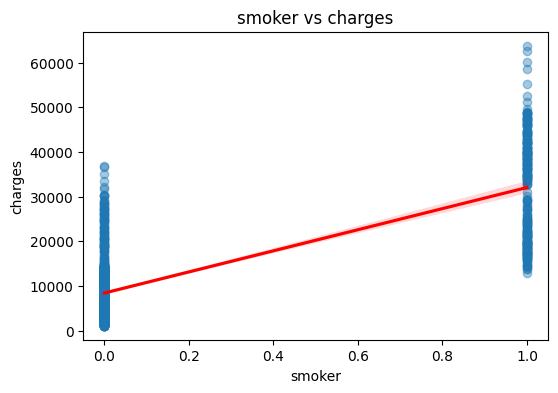

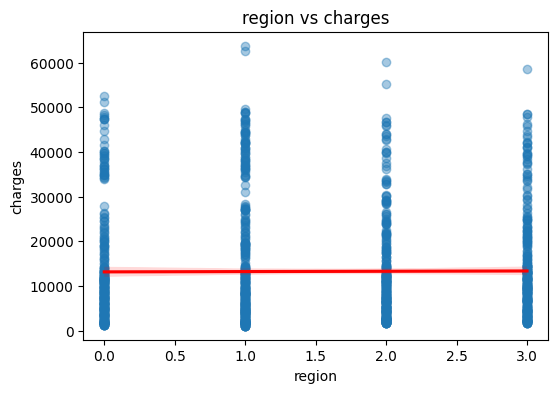

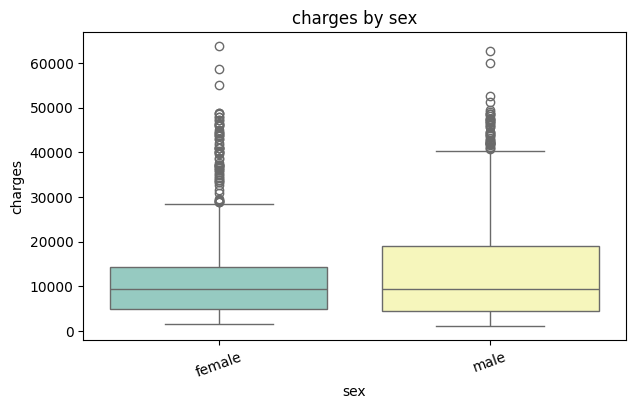

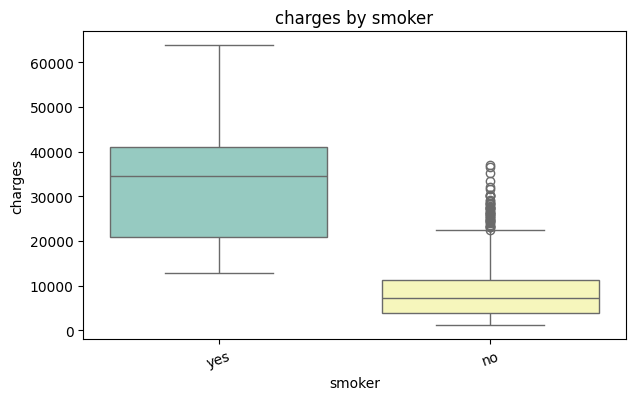

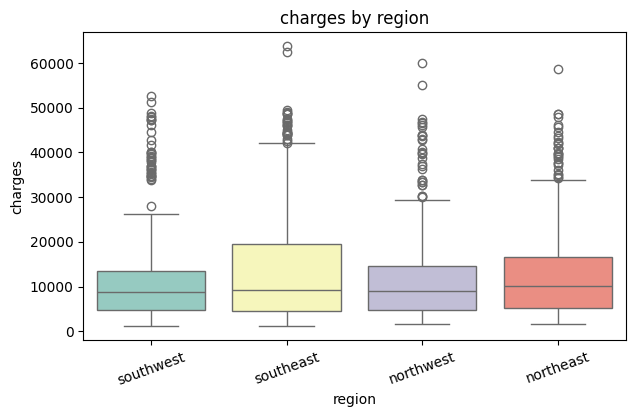

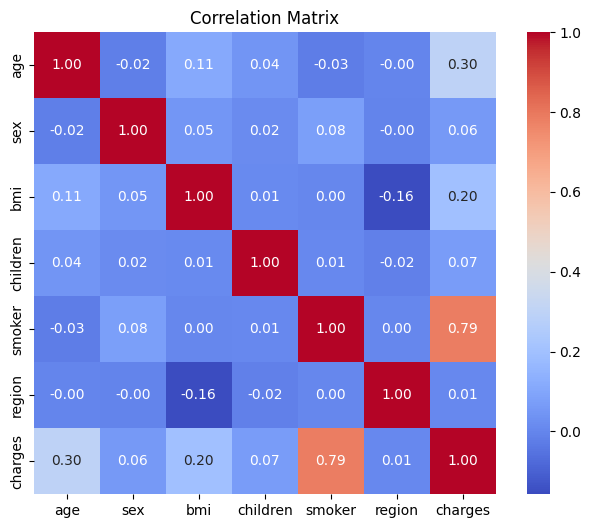

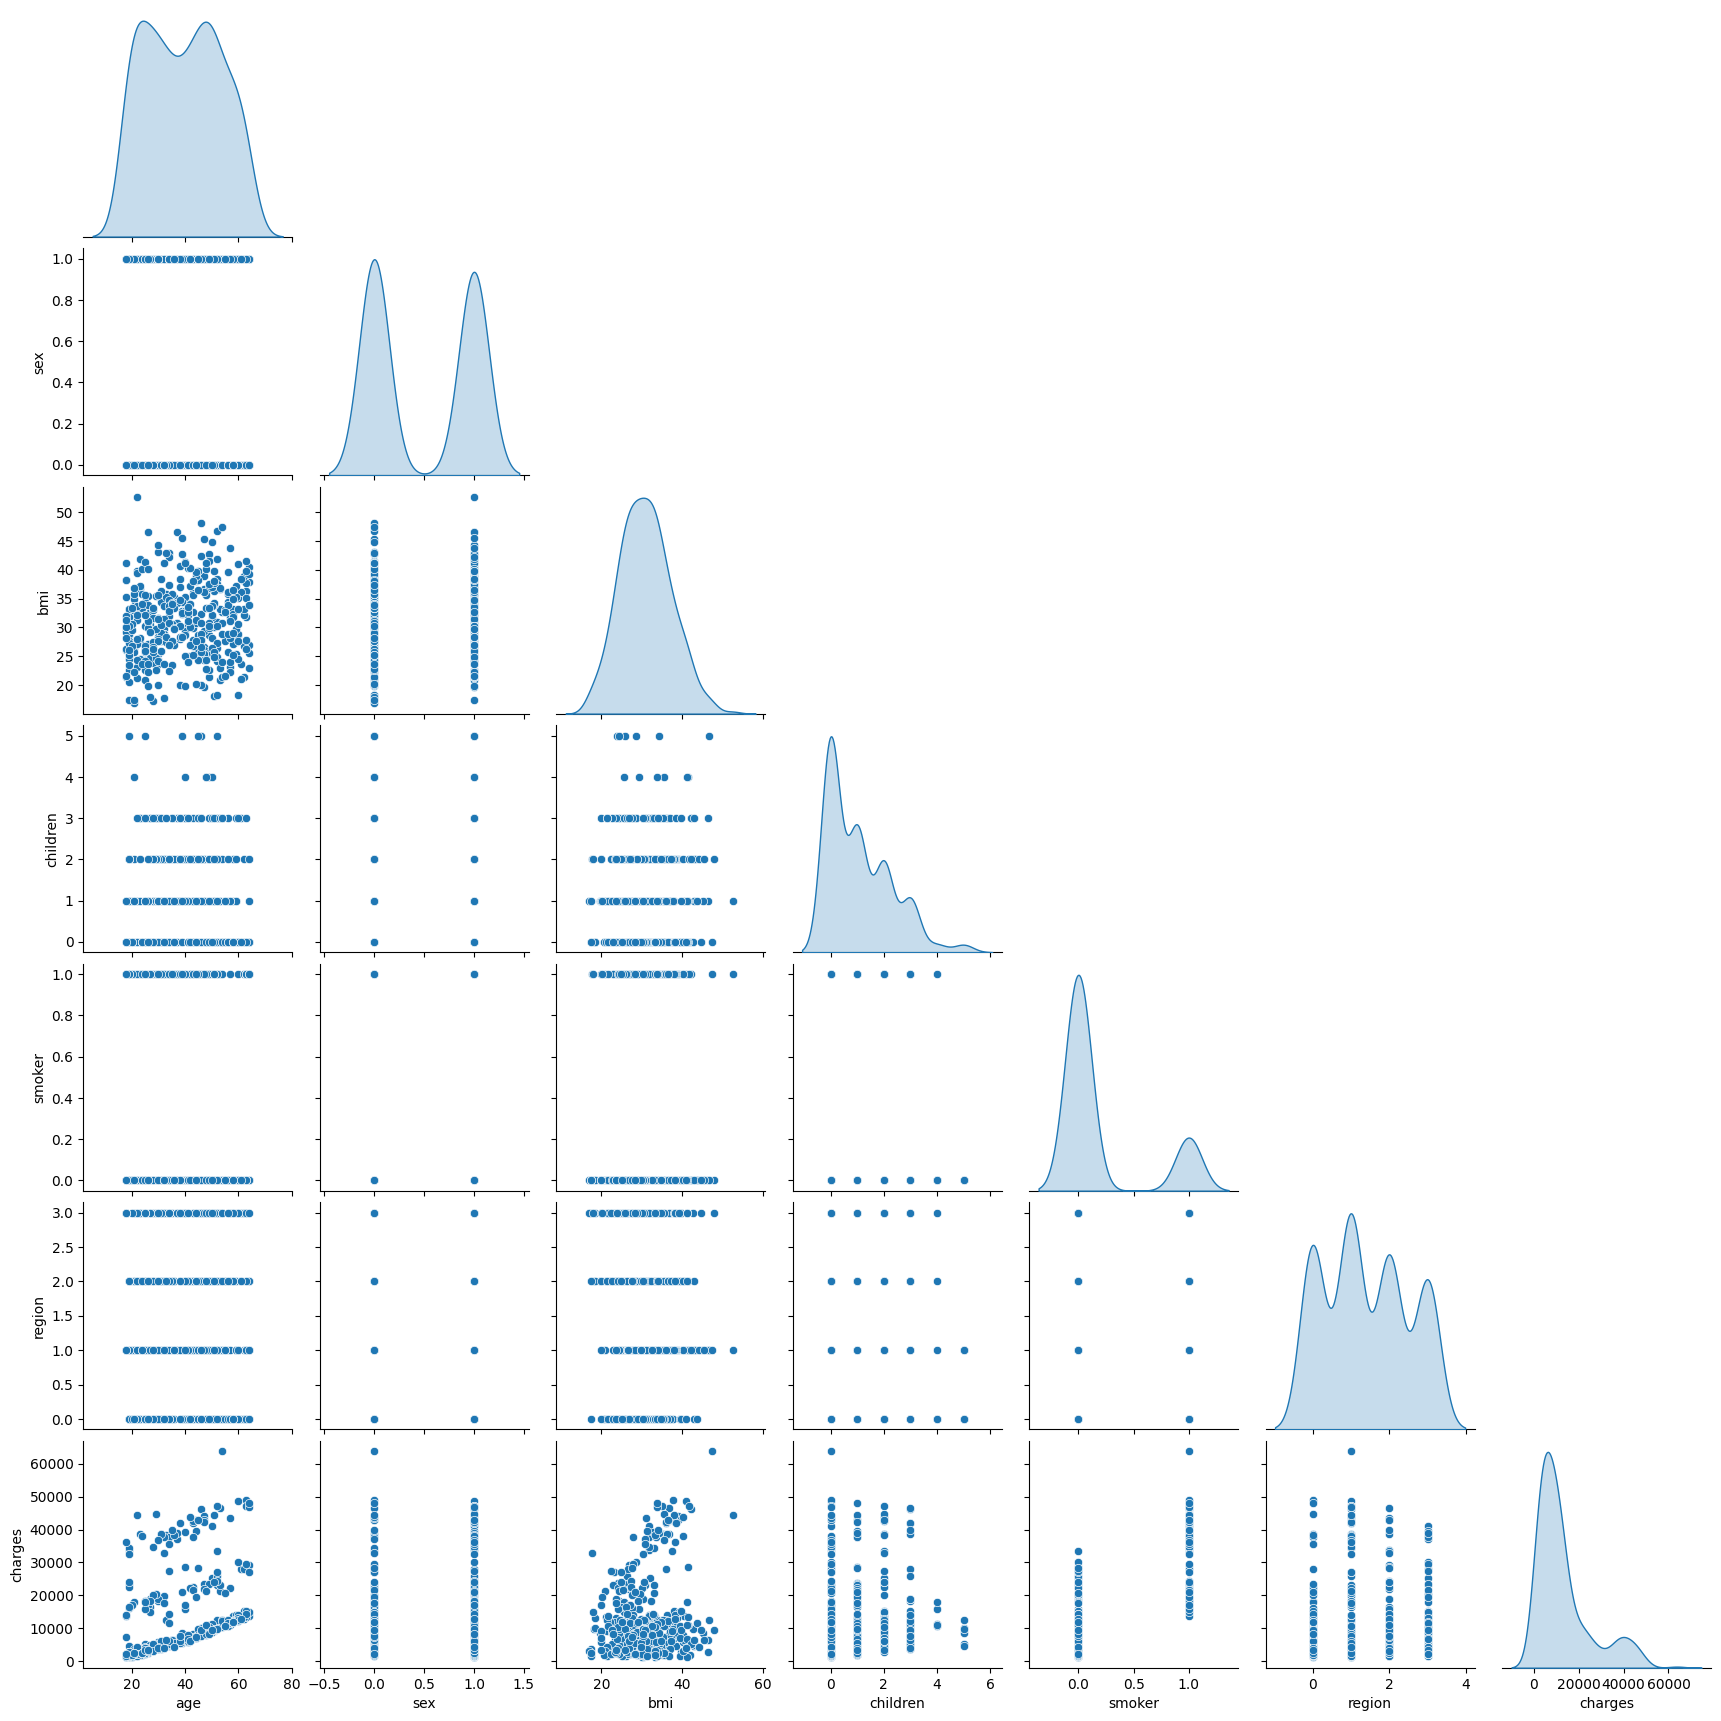

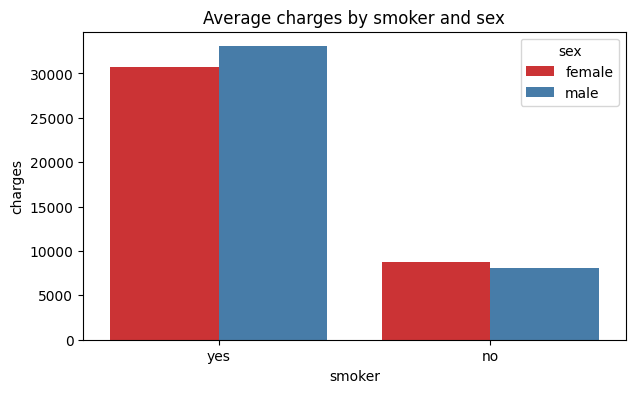

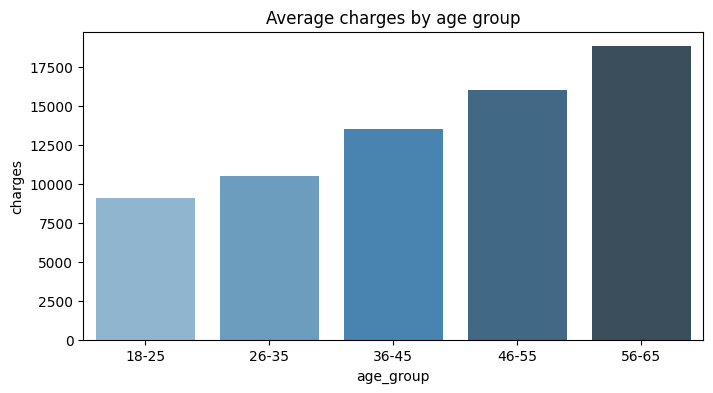

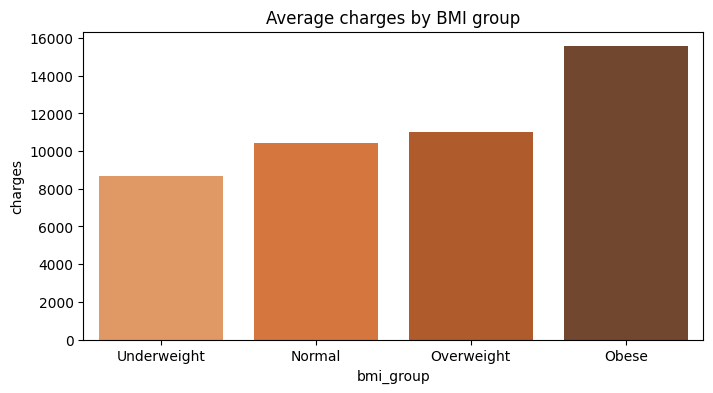


Top correlations with charges:
charges     1.000000
smoker      0.787251
age         0.299008
bmi         0.198341
children    0.067998
sex         0.057292
region      0.006208
Name: charges, dtype: float64

Average charges by smoker:
smoker
yes    32050.231832
no      8434.268298
Name: charges, dtype: float64

Average charges by region:
region
southeast    14735.411438
northeast    13406.384516
northwest    12417.575374
southwest    12346.937377
Name: charges, dtype: float64

Average charges by children:
children
0    12365.975602
1    12731.171832
2    15073.563734
3    15355.318367
4    13850.656311
5     8786.035247
Name: charges, dtype: float64


In [33]:
# Complete EDA visualization + inference summary (uses existing df, sns, plt, pd, np)

# -----------------------------
# 1) Data quality overview
# -----------------------------
print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

# -----------------------------
# 2) Feature lists (reuse existing if available)
# -----------------------------
num_cols = [c for c in df.select_dtypes(include=np.number).columns if c != "charges"]
cat_cols = [c for c in ["sex", "smoker", "region"] if c in df.columns]

# Human-readable view for categorical plots
df_vis = df.copy()
if "sex" in df_vis.columns:
    df_vis["sex"] = df_vis["sex"].map({0: "female", 1: "male"}).fillna(df_vis["sex"])
if "smoker" in df_vis.columns:
    df_vis["smoker"] = df_vis["smoker"].map({0: "no", 1: "yes"}).fillna(df_vis["smoker"])
if "region" in df_vis.columns:
    df_vis["region"] = df_vis["region"].map({0: "southwest", 1: "southeast", 2: "northwest", 3: "northeast"}).fillna(df_vis["region"])

# -----------------------------
# 3) Univariate analysis
# -----------------------------
for col in num_cols + ["charges"]:
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    sns.histplot(df[col], kde=True, bins=30, color="steelblue")
    plt.title(f"Distribution of {col}")

    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[col], color="salmon")
    plt.title(f"Boxplot of {col}")
    plt.tight_layout()
    plt.show()

for col in cat_cols:
    plt.figure(figsize=(6, 4))
    order = df_vis[col].value_counts().index
    sns.countplot(data=df_vis, x=col, order=order, palette="Set2")
    plt.title(f"Count Plot: {col}")
    plt.xticks(rotation=20)
    plt.show()

# -----------------------------
# 4) Bivariate analysis vs target (charges)
# -----------------------------
for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.regplot(data=df, x=col, y="charges", scatter_kws={"alpha": 0.4}, line_kws={"color": "red"})
    plt.title(f"{col} vs charges")
    plt.show()

for col in cat_cols:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=df_vis, x=col, y="charges", palette="Set3")
    plt.title(f"charges by {col}")
    plt.xticks(rotation=20)
    plt.show()

# -----------------------------
# 5) Correlation analysis
# -----------------------------
plt.figure(figsize=(8, 6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Correlation Matrix")
plt.show()

# Pairplot (sampled for speed/readability)
sample_n = min(400, len(df))
sns.pairplot(df.sample(sample_n, random_state=42)[num_cols + ["charges"]], corner=True, diag_kind="kde")
plt.show()

# -----------------------------
# 6) Target-driven segmented insights
# -----------------------------
if {"smoker", "sex"}.issubset(df_vis.columns):
    plt.figure(figsize=(7, 4))
    sns.barplot(data=df_vis, x="smoker", y="charges", hue="sex", estimator=np.mean, ci=None, palette="Set1")
    plt.title("Average charges by smoker and sex")
    plt.show()

# Age and BMI bins for interpretable trends
df_insight = df.copy()
df_insight["age_group"] = pd.cut(df_insight["age"], bins=[17, 25, 35, 45, 55, 65], labels=["18-25", "26-35", "36-45", "46-55", "56-65"])
df_insight["bmi_group"] = pd.cut(df_insight["bmi"], bins=[0, 18.5, 25, 30, 100], labels=["Underweight", "Normal", "Overweight", "Obese"])

plt.figure(figsize=(8, 4))
sns.barplot(data=df_insight, x="age_group", y="charges", estimator=np.mean, ci=None, palette="Blues_d")
plt.title("Average charges by age group")
plt.show()

plt.figure(figsize=(8, 4))
sns.barplot(data=df_insight, x="bmi_group", y="charges", estimator=np.mean, ci=None, palette="Oranges_d")
plt.title("Average charges by BMI group")
plt.show()

# -----------------------------
# 7) Inference tables (quick actionable outputs)
# -----------------------------
print("\nTop correlations with charges:")
print(corr["charges"].sort_values(ascending=False))

print("\nAverage charges by smoker:")
print(df_vis.groupby("smoker")["charges"].mean().sort_values(ascending=False))

print("\nAverage charges by region:")
print(df_vis.groupby("region")["charges"].mean().sort_values(ascending=False))

print("\nAverage charges by children:")
print(df.groupby("children")["charges"].mean().sort_index())

In [36]:
from sklearn.linear_model import ElasticNetCV
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)

model = ElasticNetCV(
    l1_ratio=[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0],
    alphas=[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0],
    cv=kf,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Best Alpha:", model.alpha_)
print("Best L1 Ratio:", model.l1_ratio_)


from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))


Best Alpha: 1.0
Best L1 Ratio: 1.0
MAE: 4187.244900210656
MSE: 33639339.3057476
R2: 0.7833197155138745


Train Metrics
MAE  : 4209.14
RMSE : 37280675.74
R2   : 0.7417

Test Metrics
MAE  : 4187.24
RMSE : 33639339.31
R2   : 0.7833

Overfitting Check
R2 gap (Train - Test): -0.0416
RMSE ratio (Test/Train): 0.9023
Inference: No strong overfitting signal.


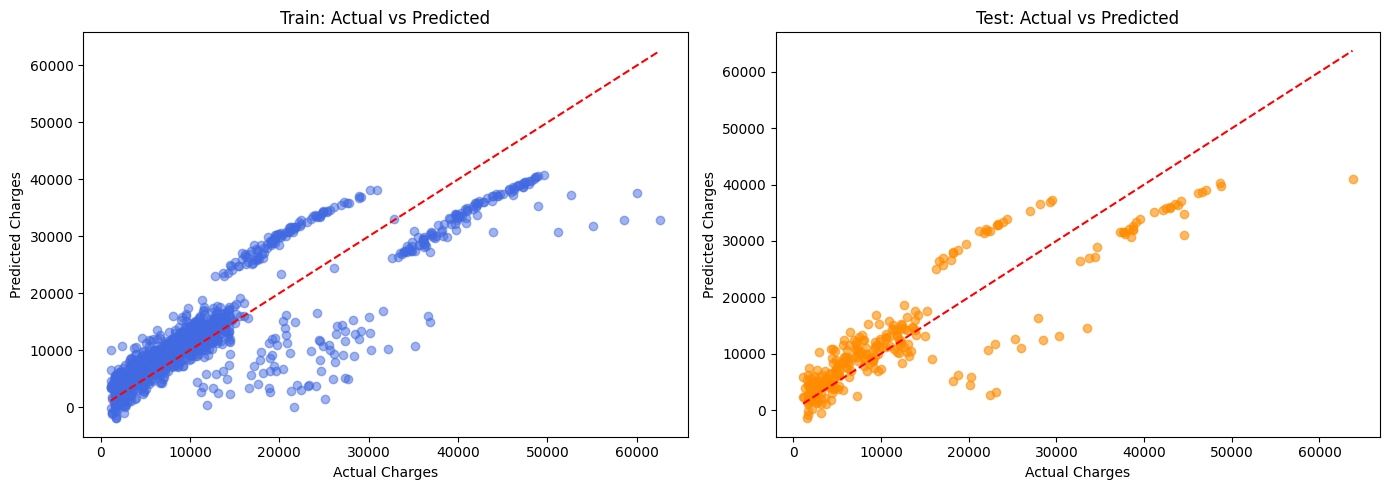

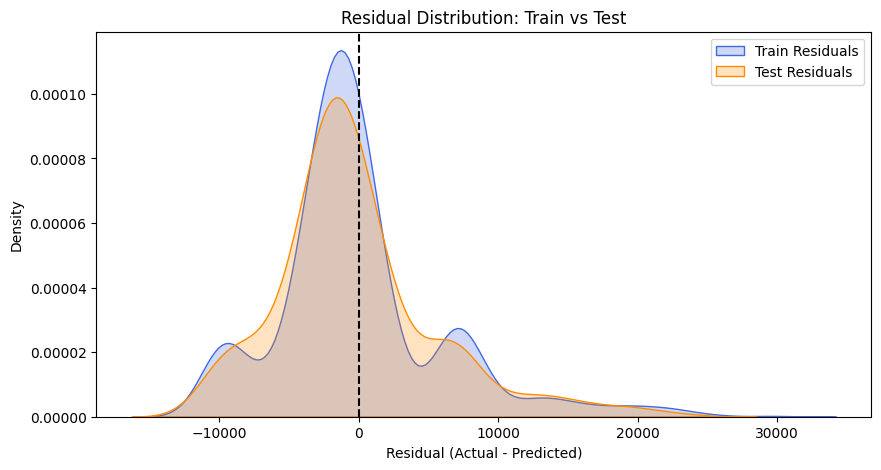

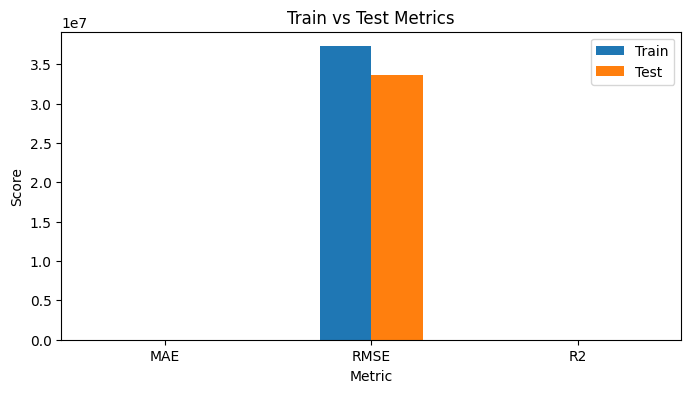

In [39]:
# Model performance visualization + overfitting check

# Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Metrics
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

train_rmse = mean_squared_error(y_train, y_train_pred)
test_rmse = mean_squared_error(y_test, y_test_pred)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("Train Metrics")
print(f"MAE  : {train_mae:.2f}")
print(f"RMSE : {train_rmse:.2f}")
print(f"R2   : {train_r2:.4f}\n")

print("Test Metrics")
print(f"MAE  : {test_mae:.2f}")
print(f"RMSE : {test_rmse:.2f}")
print(f"R2   : {test_r2:.4f}\n")

# Overfitting signal
r2_gap = train_r2 - test_r2
rmse_ratio = test_rmse / train_rmse

print("Overfitting Check")
print(f"R2 gap (Train - Test): {r2_gap:.4f}")
print(f"RMSE ratio (Test/Train): {rmse_ratio:.4f}")

if r2_gap > 0.08 or rmse_ratio > 1.25:
    print("Inference: Possible overfitting detected.")
else:
    print("Inference: No strong overfitting signal.")

# -----------------------------
# Visuals
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted (Train)
axes[0].scatter(y_train, y_train_pred, alpha=0.5, color="royalblue")
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], "r--")
axes[0].set_title("Train: Actual vs Predicted")
axes[0].set_xlabel("Actual Charges")
axes[0].set_ylabel("Predicted Charges")

# Actual vs Predicted (Test)
axes[1].scatter(y_test, y_test_pred, alpha=0.6, color="darkorange")
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
axes[1].set_title("Test: Actual vs Predicted")
axes[1].set_xlabel("Actual Charges")
axes[1].set_ylabel("Predicted Charges")

plt.tight_layout()
plt.show()

# Residual distributions
train_residuals = y_train - y_train_pred
test_residuals = y_test - y_test_pred

plt.figure(figsize=(10, 5))
sns.kdeplot(train_residuals, fill=True, label="Train Residuals", color="royalblue")
sns.kdeplot(test_residuals, fill=True, label="Test Residuals", color="darkorange")
plt.axvline(0, color="black", linestyle="--")
plt.title("Residual Distribution: Train vs Test")
plt.xlabel("Residual (Actual - Predicted)")
plt.legend()
plt.show()

# Metric comparison chart
metrics_df = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R2"],
    "Train": [train_mae, train_rmse, train_r2],
    "Test": [test_mae, test_rmse, test_r2]
})

metrics_df.set_index("Metric")[["Train", "Test"]].plot(kind="bar", figsize=(8, 4), rot=0)
plt.title("Train vs Test Metrics")
plt.ylabel("Score")
plt.show()